In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from itertools import combinations

# Time Warping

Use Time Warping to prepare the data for Non-negative matrix factorization.

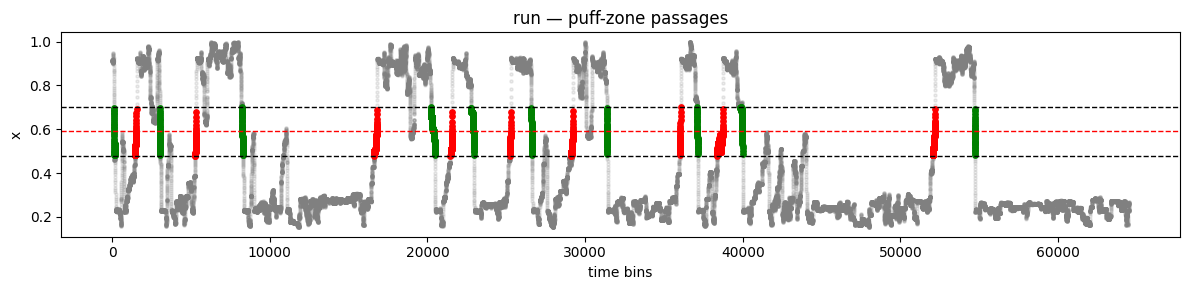

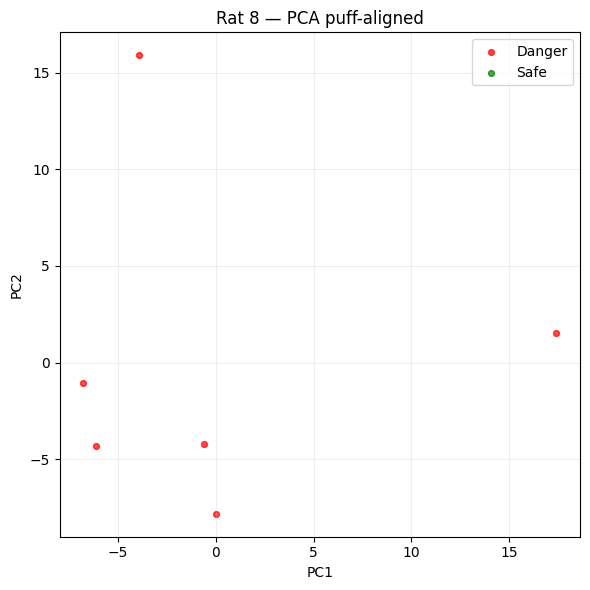

/tmp/ipykernel_9703/3209612475.py:777: RuntimeWarning: Mean of empty slice
  mean_s = aligned[y==1].mean(axis=(0,1))
/home/clairaxe/Cours/Master/Stage/mon_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


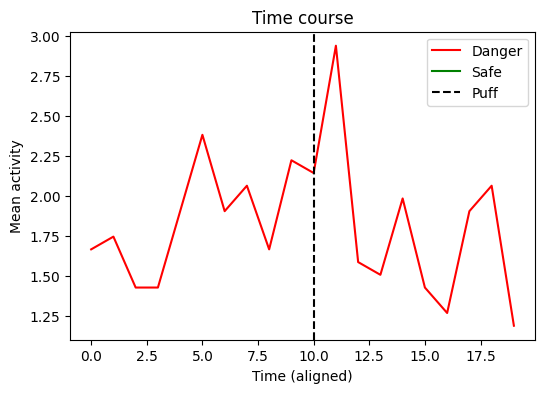


=== Rat 8 | session=run | warped passage-level PCA/NMF ===
danger_dir: 1 pos_puff: 0.5898330550918197 window: (0.4787219439807086, 0.7009441662029308)
laps total: 19
passages total: 25
passages danger/safe: 10 / 15
selected neurons: 59 (use_regions=HB, excit_only=True)
warped bins per passage: 20
flattened dataset shape: (25, 1180)
explained variance first 5 PCs: [0.0904 0.0804 0.0724 0.0638 0.056 ]

Top 5 PC pairs by CV accuracy:
PC5 vs PC6 -> accuracy = 0.960
PC1 vs PC6 -> accuracy = 0.920
PC6 vs PC8 -> accuracy = 0.920
PC3 vs PC6 -> accuracy = 0.880
PC6 vs PC13 -> accuracy = 0.880


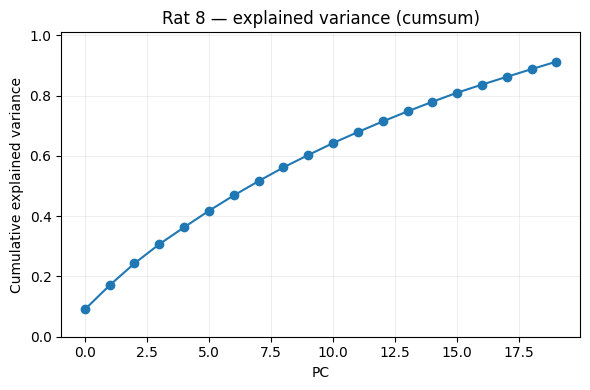

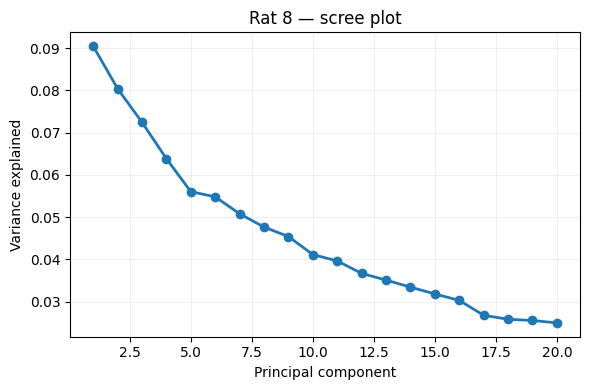

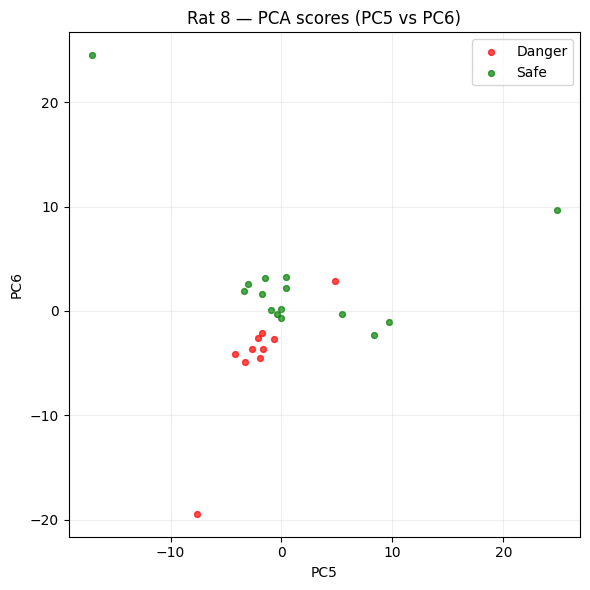

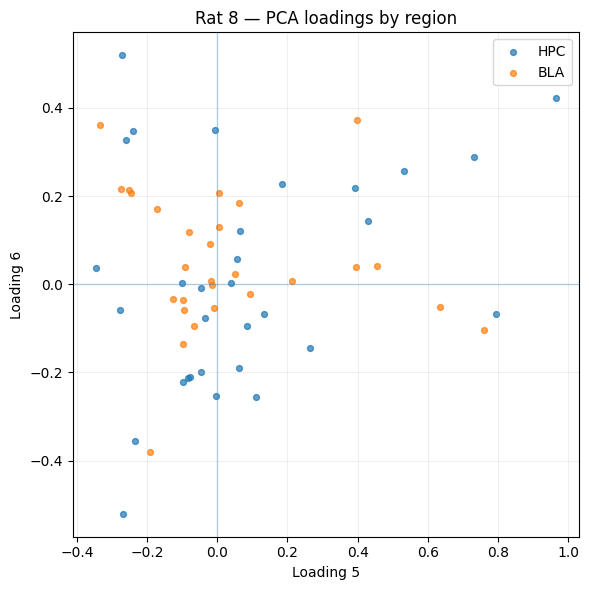

CV accuracy logistic regression on first 2 PCs: 0.600 ± 0.126
CV accuracy logistic regression on first 5 PCs: 0.600 ± 0.126

Top 10 neurons by aggregated |loading| on PC5:
  neuron   35  agg_loading=+0.9643  meta=[36 42  1  1]
  neuron   37  agg_loading=+0.7938  meta=[38 44  1  1]
  neuron   31  agg_loading=+0.7933  meta=[32 38  1  1]
  neuron  200  agg_loading=+0.7594  meta=[201 231   2   1]
  neuron   88  agg_loading=+0.7290  meta=[ 89 105   3   1]
  neuron   15  agg_loading=+0.6959  meta=[16 20  1  1]
  neuron  222  agg_loading=+0.6792  meta=[223 257   2   1]
  neuron   69  agg_loading=+0.6712  meta=[70 80  3  1]
  neuron    4  agg_loading=+0.5855  meta=[5 9 1 1]
  neuron   58  agg_loading=+0.5331  meta=[59 67  1  1]


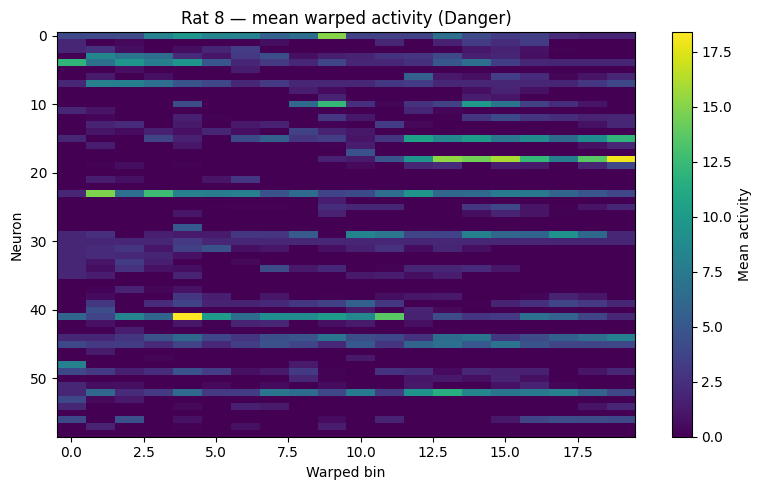

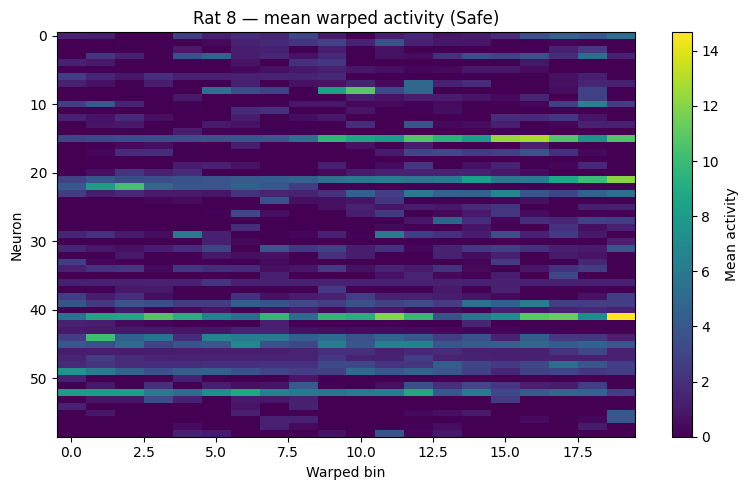


NMF reconstruction error: 757.4561
CV accuracy logistic regression on NMF components: 0.720 ± 0.098


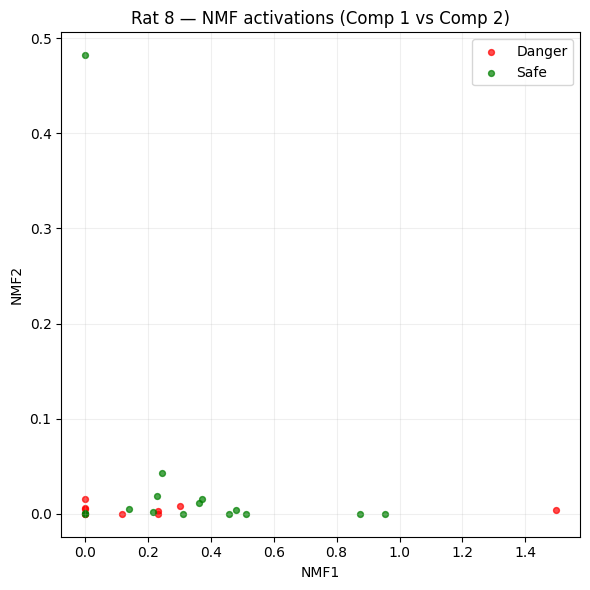

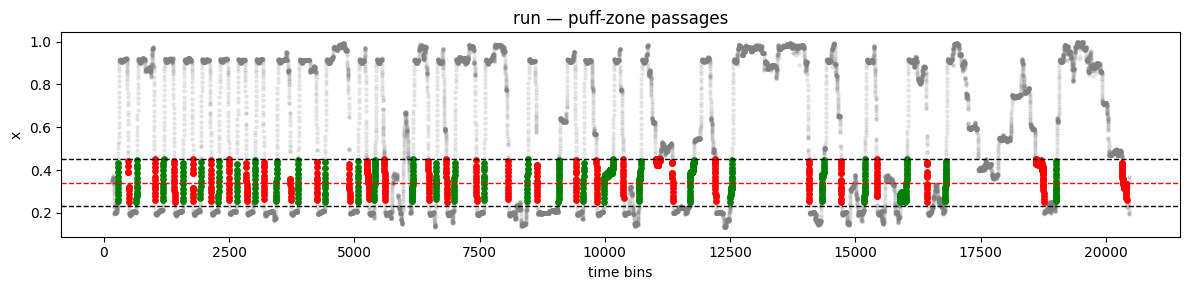

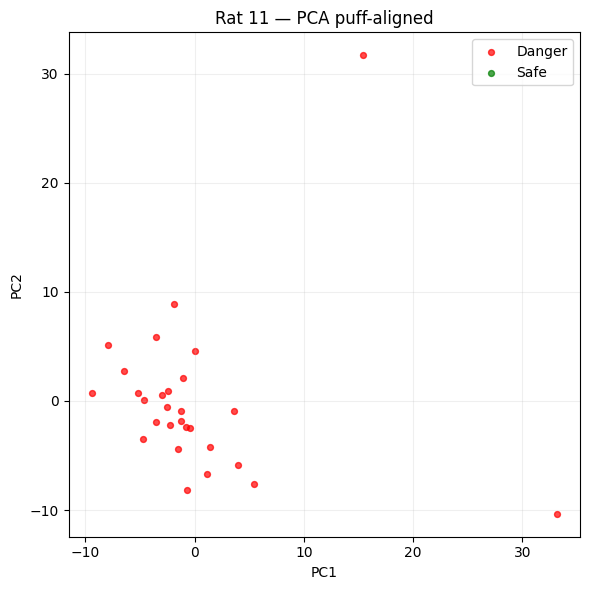

/tmp/ipykernel_9703/3209612475.py:777: RuntimeWarning: Mean of empty slice
  mean_s = aligned[y==1].mean(axis=(0,1))
/home/clairaxe/Cours/Master/Stage/mon_venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


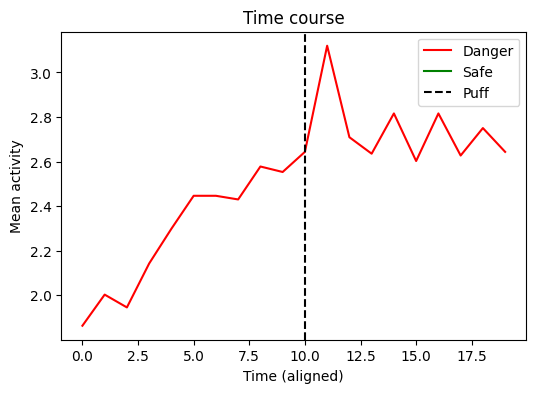


=== Rat 11 | session=run | warped passage-level PCA/NMF ===
danger_dir: -1 pos_puff: 0.34185974748086495 window: (0.23074863636975385, 0.45297085859197606)
laps total: 58
passages total: 66
passages danger/safe: 35 / 31
selected neurons: 84 (use_regions=HB, excit_only=True)
warped bins per passage: 20
flattened dataset shape: (66, 1680)
explained variance first 5 PCs: [0.0521 0.0425 0.0358 0.0301 0.0244]

Top 5 PC pairs by CV accuracy:
PC2 vs PC3 -> accuracy = 1.000
PC1 vs PC2 -> accuracy = 0.970
PC2 vs PC9 -> accuracy = 0.970
PC2 vs PC16 -> accuracy = 0.970
PC2 vs PC4 -> accuracy = 0.956


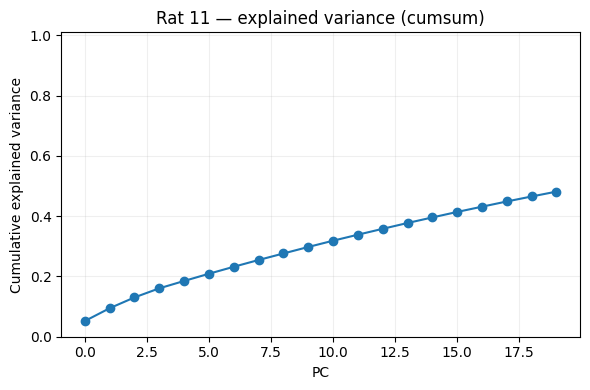

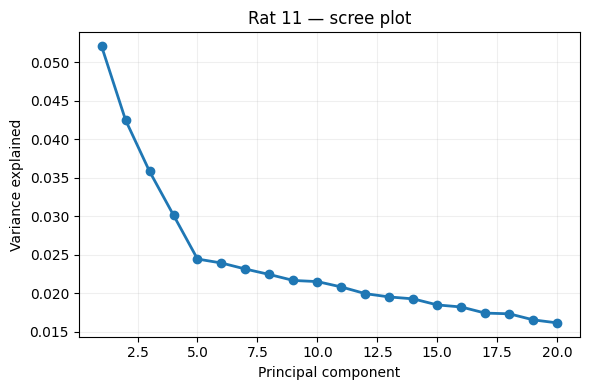

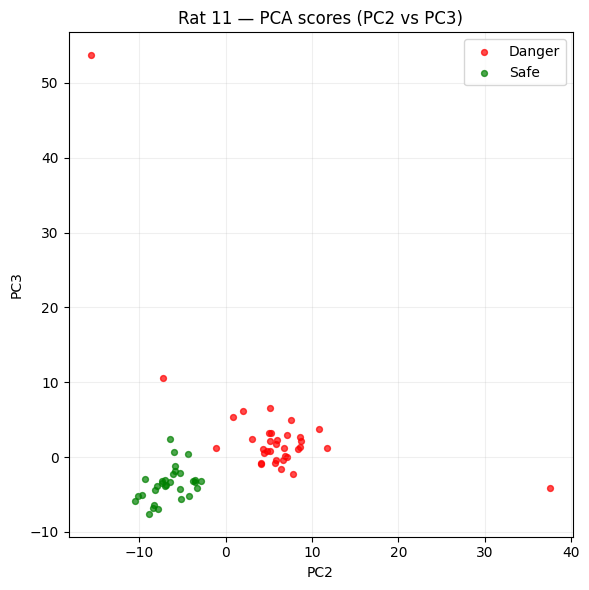

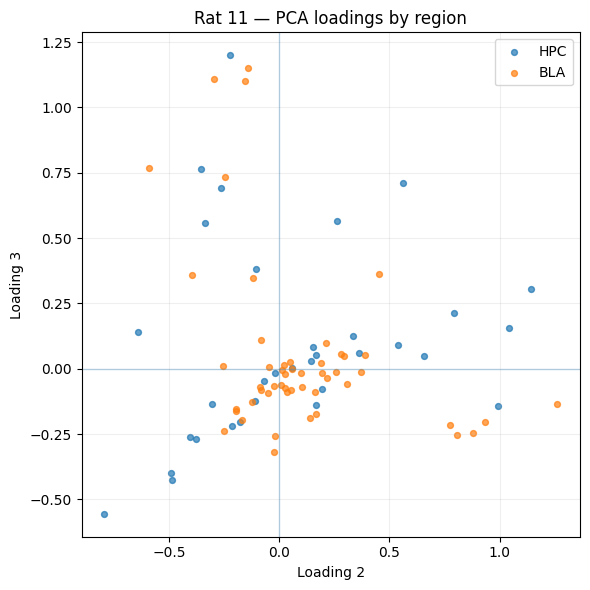

CV accuracy logistic regression on first 2 PCs: 0.970 ± 0.036
CV accuracy logistic regression on first 5 PCs: 0.970 ± 0.036

Top 10 neurons by aggregated |loading| on PC2:
  neuron   74  agg_loading=+1.2612  meta=[75 93  3  1]
  neuron  147  agg_loading=+1.1404  meta=[148 182   1   1]
  neuron  150  agg_loading=+1.0430  meta=[151 185   1   1]
  neuron  210  agg_loading=+0.9918  meta=[211 251   1   1]
  neuron   99  agg_loading=+0.9333  meta=[100 122   3   1]
  neuron  120  agg_loading=+0.8809  meta=[121 147   3   1]
  neuron  111  agg_loading=+0.8064  meta=[112 136   3   1]
  neuron  169  agg_loading=+0.8016  meta=[170 204   1   1]
  neuron  148  agg_loading=+0.7933  meta=[149 183   1   1]
  neuron   31  agg_loading=+0.7754  meta=[32 42  2  1]


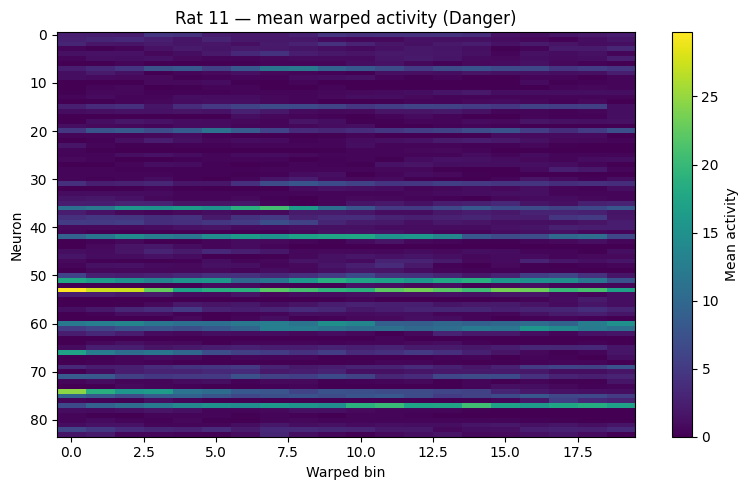

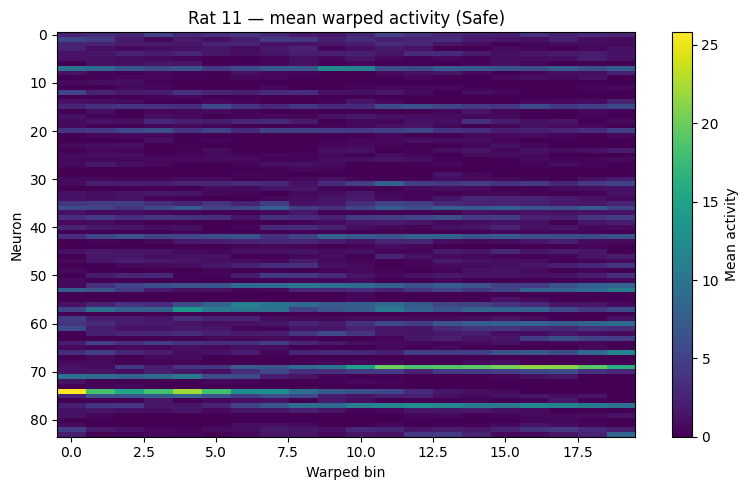


NMF reconstruction error: 1912.4350
CV accuracy logistic regression on NMF components: 0.926 ± 0.092


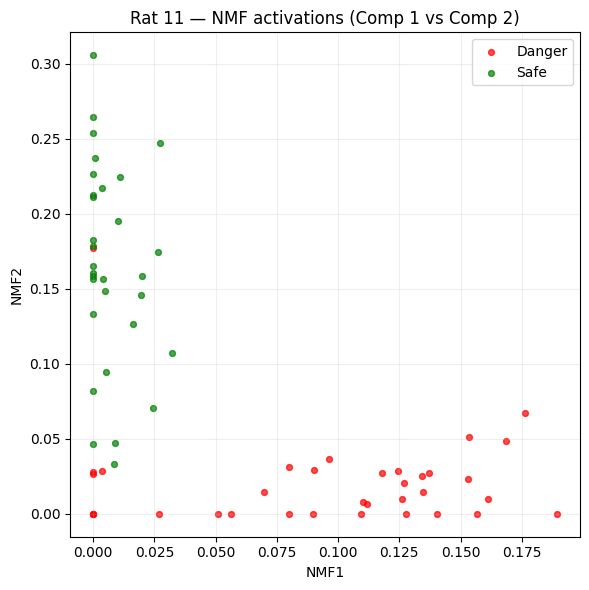

In [2]:
# ============================================================
# Goal:
#   - build puff-zone passages from *_proces_bin5.mat
#   - keep each passage separately
#   - warp each passage to a fixed number of bins
#   - run PCA and NMF on warped data
#   - plot diagnostics, separability, and top neurons
#
# Notes:
#   - time-warping here is implemented as position-based warping
#     inside each puff-zone passage
#   - PCA uses z-scored data
#   - NMF uses raw nonnegative data
# ============================================================

# ============================================================
# 1) EXTRACT / LAP FUNCTIONS
# ============================================================

def get_danger_direction(event_run):
    """
    Determine danger direction from event_run.
    Returns +1 (left->right), -1 (right->left), or 0 if undefined.
    """
    event_run = np.squeeze(event_run)

    reward_idx = np.where((event_run == 2) | (event_run == 3))[0]
    directions = []

    for i in range(len(reward_idx) - 1):
        i0, i1 = reward_idx[i], reward_idx[i + 1]
        r0 = event_run[i0]
        r1 = event_run[i1]

        if np.any(event_run[i0:i1] == 1):
            if r0 == 3 and r1 == 2:
                directions.append(+1)   # left -> right
            elif r0 == 2 and r1 == 3:
                directions.append(-1)   # right -> left

    if len(directions) == 0:
        return 0

    return int(np.sign(np.mean(directions)))


def extract_laps(
    pos, event, dt_ms,
    left=0.25, right=0.85,
    cancel_on_backtrack=True,
    eps=1e-12
):
    x = np.asarray(pos[0], dtype=float)
    ev = np.asarray(event[0]).astype(int)
    n = len(x)
    assert len(ev) == n

    zone = np.full(n, "C", dtype="<U1")
    zone[x <= left + eps] = "L"
    zone[x >= right - eps] = "R"
    zone[np.isnan(x)] = "N"

    laps = []
    state = None
    start_idx = None

    for i in range(n):
        if zone[i] == "N":
            continue

        if state is None:
            if i > 0:
                j = i - 1
                while j >= 0 and zone[j] == "N":
                    j -= 1
                if j >= 0 and zone[j] == "L" and zone[i] == "C":
                    state = "LR"
                    start_idx = i
                elif j >= 0 and zone[j] == "R" and zone[i] == "C":
                    state = "RL"
                    start_idx = i

        else:
            if state == "LR":
                if cancel_on_backtrack and zone[i] == "L":
                    state = None
                    start_idx = None
                    continue

                if zone[i] == "R":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[
                        (~np.isnan(x[idx])) &
                        (x[idx] >= left - eps) &
                        (x[idx] <= right + eps)
                    ]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": +1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None
                    start_idx = None

            elif state == "RL":
                if cancel_on_backtrack and zone[i] == "R":
                    state = None
                    start_idx = None
                    continue

                if zone[i] == "L":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[
                        (~np.isnan(x[idx])) &
                        (x[idx] >= left - eps) &
                        (x[idx] <= right + eps)
                    ]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": -1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None
                    start_idx = None

    return laps


def label_laps_with_danger(laps, danger_dir):
    for lap in laps:
        lap["is_danger"] = (lap["dir"] == danger_dir)
    return laps


# ============================================================
# 2) HELPERS
# ============================================================

def estimate_pos_puff_from_run(pos_run, event_run):
    """Median x position during puff bins (event == 1) in RUN."""
    x_run = np.asarray(pos_run[0], dtype=float)
    ev = np.asarray(event_run[0]).astype(int)
    puff_idx = np.where(ev == 1)[0]
    if puff_idx.size == 0:
        raise ValueError("No puff bins found in event.run == 1. Cannot estimate pos_puff.")
    return float(np.nanmedian(x_run[puff_idx]))


def split_contiguous_indices(idx):
    """Split 1D sorted indices into contiguous chunks (diff == 1)."""
    idx = np.asarray(idx, dtype=int)
    if idx.size == 0:
        return []
    cuts = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[0, cuts + 1]
    ends = np.r_[cuts + 1, idx.size]
    return [idx[s:e] for s, e in zip(starts, ends)]


def select_neurons(metadata, use_regions="HB", excit_only=True):
    """
    metadata columns (0-based):
      col2: region  (1 dHPC, 2 rBLA, 3 lBLA, 4 Pir)
      col3: type    (1 pyramidal, 2 interneuron)
    """
    meta = np.asarray(metadata)
    region = meta[:, 2].astype(int)
    ntype = meta[:, 3].astype(int)

    keep = np.ones(meta.shape[0], dtype=bool)

    if excit_only:
        keep &= (ntype == 1)

    is_hpc = (region == 1)
    is_bla = np.isin(region, [2, 3])
    is_hb = is_hpc | is_bla

    if use_regions == "HPC":
        keep &= is_hpc
    elif use_regions == "BLA":
        keep &= is_bla
    elif use_regions == "HB":
        keep &= is_hb
    else:
        raise ValueError("use_regions must be 'HPC', 'BLA', or 'HB'")

    idx = np.where(keep)[0]
    idx_hpc = np.where((ntype == 1) & is_hpc)[0]
    idx_bla = np.where((ntype == 1) & is_bla)[0]

    return idx, idx_hpc, idx_bla


# ============================================================
# 3) EXTRACT INDIVIDUAL PASSAGES
# ============================================================

def extract_passage_list_from_proces(
    data_full,
    session="run",
    dt_ms=50,
    corridor_left=0.25,
    corridor_right=0.85,
    halfwidth_cm=20,
    track_length_cm=180,
    cancel_on_backtrack=True,
    min_bins_per_passage=2,
    eps=1e-12,
):
    """
    Return a list of individual puff-zone passages.

    Each passage is a dict with:
      - spk: neurons x L
      - x:   position values, length L
      - is_danger: bool
      - dir, lap, t_start, t_end, len_bins
    """
    spk_sess = data_full["spik"][session][0, 0].astype(float)   # neurons x T
    pos_sess = data_full["posit"][session][0, 0].astype(float)  # 2 x T
    event_sess = data_full["event"][session][0, 0]

    pos_run = data_full["posit"]["run"][0, 0].astype(float)
    event_run = data_full["event"]["run"][0, 0]

    danger_dir = get_danger_direction(event_run)
    pos_puff = estimate_pos_puff_from_run(pos_run, event_run)

    delta = halfwidth_cm / track_length_cm
    left_win = pos_puff - delta
    right_win = pos_puff + delta

    laps = extract_laps(
        pos_sess, event_sess, dt_ms,
        left=corridor_left,
        right=corridor_right,
        cancel_on_backtrack=cancel_on_backtrack,
        eps=eps
    )
    laps = label_laps_with_danger(laps, danger_dir)

    x = np.asarray(pos_sess[0], dtype=float)

    passages = []

    for lap in laps:
        idx = lap["idx"]

        inside = idx[
            (~np.isnan(x[idx])) &
            (x[idx] >= left_win - eps) &
            (x[idx] <= right_win + eps)
        ]

        if inside.size < min_bins_per_passage:
            continue

        chunks = split_contiguous_indices(inside)

        for ch in chunks:
            if ch.size < min_bins_per_passage:
                continue

            passages.append({
                "lap": lap["lap"],
                "dir": lap["dir"],
                "is_danger": lap["is_danger"],
                "t_start": int(ch[0]),
                "t_end": int(ch[-1]),
                "len_bins": int(ch.size),
                "spk": spk_sess[:, ch].copy(),   # neurons x L
                "x": x[ch].copy(),               # length L
            })

    if len(passages) == 0:
        raise ValueError(f"No puff-zone passages found in session={session}.")

    info = {
        "session": session,
        "danger_dir": danger_dir,
        "pos_puff": pos_puff,
        "window": (left_win, right_win),
        "n_laps_total": len(laps),
        "n_passages_total": len(passages),
        "n_passages_danger": int(np.sum([p["is_danger"] for p in passages])),
        "n_passages_safe": int(np.sum([not p["is_danger"] for p in passages])),
        "passages": passages,
    }

    return passages, info


def plot_puff_passages_sanity(data_full, info, session="run"):
    """Sanity plot: only real time bins are shown."""
    pos = data_full["posit"][session][0, 0].astype(float)
    x = np.asarray(pos[0], float)

    left, right = info["window"]
    pos_puff = info["pos_puff"]

    plt.figure(figsize=(12, 3))

    valid = ~np.isnan(x)
    plt.scatter(np.where(valid)[0], x[valid], s=5, alpha=0.15, color="gray", label="all valid bins")

    plt.axhline(left, color="k", ls="--", lw=1)
    plt.axhline(right, color="k", ls="--", lw=1)
    plt.axhline(pos_puff, color="r", ls="--", lw=1, label="puff center")

    for p in info["passages"]:
        t0, t1 = p["t_start"], p["t_end"]
        idx = np.arange(t0, t1 + 1)
        col = "red" if p["is_danger"] else "green"
        plt.scatter(idx, x[idx], s=15, color=col)

    plt.title(f"{session} — puff-zone passages")
    plt.xlabel("time bins")
    plt.ylabel("x")
    plt.tight_layout()
    plt.show()


# ============================================================
# 4) WARPING
# ============================================================

def warp_passage_by_position(spk, x, n_bins=20, eps=1e-12):
    """
    Warp one passage to a fixed number of bins using normalized position.

    Parameters
    ----------
    spk : array, shape (N, L)
        Spike counts or firing rates for one passage
    x : array, shape (L,)
        Position values for the same passage
    n_bins : int
        Number of warped bins

    Returns
    -------
    spk_warp : array, shape (N, n_bins)
    """
    spk = np.asarray(spk, float)
    x = np.asarray(x, float)

    valid = ~np.isnan(x)
    x = x[valid]
    spk = spk[:, valid]

    if x.size < 2:
        raise ValueError("Passage too short for warping.")

    # always orient from smaller x to larger x
    if x[0] > x[-1]:
        x = x[::-1]
        spk = spk[:, ::-1]

    xmin, xmax = x[0], x[-1]
    if abs(xmax - xmin) < eps:
        return np.repeat(spk.mean(axis=1, keepdims=True), n_bins, axis=1)

    x_norm = (x - xmin) / (xmax - xmin)
    grid = np.linspace(0.0, 1.0, n_bins)

    spk_warp = np.empty((spk.shape[0], n_bins), dtype=float)
    for n in range(spk.shape[0]):
        spk_warp[n] = np.interp(grid, x_norm, spk[n])

    return spk_warp


def build_warped_dataset(
    passages,
    neuron_idx,
    n_warp_bins=20,
    min_mean_fr=0.2,
):
    """
    Build warped datasets from individual passages.

    Returns
    -------
    X_flat : (P, N*B)
        one row per passage
    X_time : (P*B, N)
        one row per warped bin
    y_passage : (P,)
        0=danger, 1=safe
    y_time : (P*B,)
        repeated labels
    kept_neuron_idx : array
        selected neurons after FR threshold
    warped : (P, N, B)
        warped tensor
    """
    warped = []
    labels = []

    for p in passages:
        spk = p["spk"][neuron_idx, :]
        x = p["x"]
        spk_warp = warp_passage_by_position(spk, x, n_bins=n_warp_bins)
        warped.append(spk_warp)
        labels.append(0 if p["is_danger"] else 1)

    warped = np.stack(warped, axis=0)   # (P, N, B)
    labels = np.asarray(labels, dtype=int)

    mean_fr = warped.mean(axis=(0, 2))
    keep = mean_fr > min_mean_fr

    if np.sum(keep) == 0:
        raise ValueError("No neurons remain after firing-rate thresholding.")

    warped = warped[:, keep, :]
    kept_neuron_idx = neuron_idx[keep]

    X_flat = warped.reshape(warped.shape[0], -1)
    X_time = warped.transpose(0, 2, 1).reshape(-1, warped.shape[1])
    y_time = np.repeat(labels, warped.shape[2])

    return X_flat, X_time, labels, y_time, kept_neuron_idx, warped


# ============================================================
# 5) PCA / NMF
# ============================================================

def fit_pca_zscore(X, n_components=10, seed=0):
    Xz = StandardScaler(with_mean=True, with_std=True).fit_transform(X)
    pca = PCA(n_components=n_components, random_state=seed)
    score = pca.fit_transform(Xz)
    coeff = pca.components_.T
    return pca, score, coeff


def fit_nmf(X, n_components=5, seed=0, max_iter=1000):
    if np.any(X < 0):
        raise ValueError("NMF requires nonnegative input.")
    model = NMF(
        n_components=n_components,
        init="nndsvda",
        random_state=seed,
        max_iter=max_iter
    )
    W = model.fit_transform(X)
    H = model.components_
    return model, W, H


# ============================================================
# 6) PLOTS / DIAGNOSTICS
# ============================================================

def plot_variance_cumsum(pca, title):
    plt.figure(figsize=(6, 4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
    plt.xlabel("PC")
    plt.ylabel("Cumulative explained variance")
    plt.ylim(0, 1.01)
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_scree(pca, title):
    plt.figure(figsize=(6, 4))
    pc_values = np.arange(1, pca.n_components_ + 1)
    plt.plot(pc_values, pca.explained_variance_ratio_, 'o-', linewidth=2)
    plt.xlabel("Principal component")
    plt.ylabel("Variance explained")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_scores_danger_safe(score, y, title, pcx=0, pcy=1):
    plt.figure(figsize=(6, 6))
    plt.scatter(score[y == 0, pcx], score[y == 0, pcy],
                s=18, alpha=0.7, color="red", label="Danger")
    plt.scatter(score[y == 1, pcx], score[y == 1, pcy],
                s=18, alpha=0.7, color="green", label="Safe")
    plt.xlabel(f"PC{pcx + 1}")
    plt.ylabel(f"PC{pcy + 1}")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_nmf_scores_danger_safe(W, y, title, cx=0, cy=1):
    plt.figure(figsize=(6, 6))
    plt.scatter(W[y == 0, cx], W[y == 0, cy],
                s=18, alpha=0.7, color="red", label="Danger")
    plt.scatter(W[y == 1, cx], W[y == 1, cy],
                s=18, alpha=0.7, color="green", label="Safe")
    plt.xlabel(f"NMF{cx + 1}")
    plt.ylabel(f"NMF{cy + 1}")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_loadings_by_region(coeff, neuron_idx, idx_hpc, idx_bla, title, pcx=0, pcy=1):
    """
    coeff is (N_selected x K).
    neuron_idx: selected full indices -> corresponds to coeff rows.
    idx_hpc / idx_bla: full indices for region coloring.
    """
    full_to_sel = {full_i: sel_i for sel_i, full_i in enumerate(neuron_idx)}
    sel_hpc = np.array([full_to_sel[i] for i in idx_hpc if i in full_to_sel], dtype=int)
    sel_bla = np.array([full_to_sel[i] for i in idx_bla if i in full_to_sel], dtype=int)

    plt.figure(figsize=(6, 6))
    if sel_hpc.size:
        plt.scatter(coeff[sel_hpc, pcx], coeff[sel_hpc, pcy], s=18, alpha=0.7, label="HPC")
    if sel_bla.size:
        plt.scatter(coeff[sel_bla, pcx], coeff[sel_bla, pcy], s=18, alpha=0.7, label="BLA")

    plt.axhline(0, lw=1, alpha=0.3)
    plt.axvline(0, lw=1, alpha=0.3)
    plt.xlabel(f"Loading {pcx + 1}")
    plt.ylabel(f"Loading {pcy + 1}")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_warped_heatmap_mean(warped, y, title, class_value=0):
    """
    warped: (P, N, B)
    class_value: 0=danger, 1=safe
    """
    if np.sum(y == class_value) == 0:
        return

    mean_map = warped[y == class_value].mean(axis=0)  # (N, B)

    plt.figure(figsize=(8, 5))
    plt.imshow(mean_map, aspect="auto", interpolation="nearest")
    plt.xlabel("Warped bin")
    plt.ylabel("Neuron")
    plt.title(title)
    plt.colorbar(label="Mean activity")
    plt.tight_layout()
    plt.show()


# ============================================================
# 7) SEPARABILITY / TOP FEATURES
# ============================================================

def separability_cv(score, y, dims=2, seed=0):
    Xp = score[:, :dims]
    clf = LogisticRegression(max_iter=5000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    acc = cross_val_score(clf, Xp, y, cv=cv, scoring="accuracy")
    return acc.mean(), acc.std()


def separability_cv_on_first_dims(score, y, dims=2, seed=0):
    Xp = score[:, :dims]
    return separability_cv(Xp, y, seed=seed)


def best_pc_pairs(score, y, max_pc=20, seed=0):
    results = []
    k = min(max_pc, score.shape[1])

    clf = LogisticRegression(max_iter=5000, class_weight="balanced")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for i, j in combinations(range(k), 2):
        Xp = score[:, [i, j]]
        acc = cross_val_score(clf, Xp, y, cv=cv, scoring="accuracy").mean()
        results.append((i, j, acc))

    results.sort(key=lambda x: x[2], reverse=True)
    return results


def top_neurons_by_pc_from_flattened_loadings(coeff_flat, neuron_idx, metadata, n_warp_bins, pc=0, top_k=10):
    """
    coeff_flat : shape (N*B, K), PCA loadings on flattened features
    We aggregate |loadings| across warped bins for each neuron.
    """
    n_features = coeff_flat.shape[0]
    n_neurons = len(neuron_idx)
    assert n_features == n_neurons * n_warp_bins

    coeff_pc = coeff_flat[:, pc].reshape(n_neurons, n_warp_bins)
    weights = np.sum(np.abs(coeff_pc), axis=1)

    order = np.argsort(weights)[::-1][:top_k]
    top_full = neuron_idx[order]

    out = []
    for sel_i, full_i in zip(order, top_full):
        out.append((int(full_i), float(weights[sel_i]), metadata[full_i, :].copy()))
    return out

# IMPORTANT ADDITION !!!
def extract_puff_time_for_passage(passage, event_sess):
    """
    Find puff time inside a passage.
    Returns index (int) or None.
    """
    t0 = passage["t_start"]
    t1 = passage["t_end"]

    ev = np.asarray(event_sess[0]).astype(int)

    puff_idx = np.where(ev == 1)[0]
    puff_in = puff_idx[(puff_idx >= t0) & (puff_idx <= t1)]

    if len(puff_in) == 0:
        return None

    return puff_in[0]  # first puff

def build_puff_aligned_dataset(
    passages,
    data_full,
    neuron_idx,
    session="run",
    Tpre=10,
    Tpost=10,
    min_mean_fr=0.2
):
    """
    Build dataset aligned on puff (t=0).
    """

    spk_sess = data_full["spik"][session][0, 0].astype(float)
    event_sess = data_full["event"][session][0, 0]

    aligned = []
    labels = []

    for p in passages:

        puff_t = extract_puff_time_for_passage(p, event_sess)

        if puff_t is None:
            continue

        idx = np.arange(puff_t - Tpre, puff_t + Tpost)

        # sécurité (bord du signal)
        if idx[0] < 0 or idx[-1] >= spk_sess.shape[1]:
            continue

        spk = spk_sess[:, idx]  # neurons x time window

        aligned.append(spk[neuron_idx, :])
        labels.append(0 if p["is_danger"] else 1)

    aligned = np.stack(aligned, axis=0)  # (P, N, T)
    labels = np.asarray(labels)

    # filtre FR
    mean_fr = aligned.mean(axis=(0, 2))
    keep = mean_fr > min_mean_fr

    aligned = aligned[:, keep, :]
    kept_neuron_idx = neuron_idx[keep]

    # formats PCA
    X_flat = aligned.reshape(aligned.shape[0], -1)
    X_time = aligned.transpose(0, 2, 1).reshape(-1, aligned.shape[1])
    y_time = np.repeat(labels, aligned.shape[2])

    return X_flat, X_time, labels, y_time, kept_neuron_idx, aligned

# ============================================================
# 8) MAIN PIPELINE FOR ONE RAT
# ============================================================

def run_rat_proces_warped_pca_nmf(
    path,
    rat_name="Rat?",
    session="run",
    dt_ms=50,
    use_regions="HB",
    excit_only=True,
    n_warp_bins=20,
    n_pca_components=20,
    n_nmf_components=4,
    min_mean_fr=0.2,
    seed=0,
):
    data = scipy.io.loadmat(path)
    metadata = data["metadata"]

    # 1) extract passages
    passages, info = extract_passage_list_from_proces(
        data,
        session=session,
        dt_ms=dt_ms,
        corridor_left=0.25,
        corridor_right=0.85,
        halfwidth_cm=20,
        track_length_cm=180,
        cancel_on_backtrack=True,
        min_bins_per_passage=2,
    )

    # 2) sanity plot
    plot_puff_passages_sanity(data, info, session=session)

    # 3) neuron selection
    neuron_idx, idx_hpc, idx_bla = select_neurons(
        metadata,
        use_regions=use_regions,
        excit_only=excit_only
    )

    # 4) build warped dataset
    X_flat, X_time, y_passage, y_time, kept_neuron_idx, warped = build_warped_dataset(
        passages,
        neuron_idx,
        n_warp_bins=n_warp_bins,
        min_mean_fr=min_mean_fr,
    )

    # NEW: puff-aligned dataset
    X_flat_align, X_time_align, y_passage_align, y_time_align, neuron_idx_align, aligned = build_puff_aligned_dataset(
        passages,
        data,
        neuron_idx,
        session=session,
        Tpre=10,
        Tpost=10,
        min_mean_fr=min_mean_fr
    )

    pca_align, score_align, coeff_align = fit_pca_zscore(
        X_flat_align,
        n_components=min(n_pca_components, X_flat_align.shape[0]-1),
        seed=seed
    )

    plot_scores_danger_safe(
        score_align,
        y_passage_align,
        f"{rat_name} — PCA puff-aligned",
        pcx=0, pcy=1
    )

    def plot_mean_timecourse(aligned, y, title):
        plt.figure(figsize=(6,4))

        t = np.arange(aligned.shape[2])

        mean_d = aligned[y==0].mean(axis=(0,1))
        mean_s = aligned[y==1].mean(axis=(0,1))

        plt.plot(t, mean_d, label="Danger", color="red")
        plt.plot(t, mean_s, label="Safe", color="green")

        plt.axvline(aligned.shape[2]//2, linestyle="--", color="black", label="Puff")

        plt.xlabel("Time (aligned)")
        plt.ylabel("Mean activity")
        plt.title(title)
        plt.legend()
        plt.show()

    plot_mean_timecourse(aligned, y_passage_align, "Time course")

    # 5) PCA on flattened warped passages
    ncomp = min(n_pca_components, X_flat.shape[1], X_flat.shape[0] - 1)
    pca, score, coeff = fit_pca_zscore(X_flat, n_components=ncomp, seed=seed)


    pairs = best_pc_pairs(score, y_passage, max_pc=min(20, score.shape[1]), seed=seed)

    print(f"\n=== {rat_name} | session={session} | warped passage-level PCA/NMF ===")
    print("danger_dir:", info["danger_dir"], "pos_puff:", info["pos_puff"], "window:", info["window"])
    print("laps total:", info["n_laps_total"])
    print("passages total:", info["n_passages_total"])
    print("passages danger/safe:", info["n_passages_danger"], "/", info["n_passages_safe"])
    print("selected neurons:", len(kept_neuron_idx), f"(use_regions={use_regions}, excit_only={excit_only})")
    print("warped bins per passage:", n_warp_bins)
    print("flattened dataset shape:", X_flat.shape)
    print("explained variance first 5 PCs:", np.round(pca.explained_variance_ratio_[:5], 4))

    if len(pairs) > 0:
        print("\nTop 5 PC pairs by CV accuracy:")
        for i, j, acc in pairs[:5]:
            print(f"PC{i + 1} vs PC{j + 1} -> accuracy = {acc:.3f}")
        best_i, best_j, _ = pairs[0]
    else:
        best_i, best_j = 0, 1 if score.shape[1] > 1 else 0

    # 6) PCA plots
    plot_variance_cumsum(pca, f"{rat_name} — explained variance (cumsum)")
    plot_scree(pca, f"{rat_name} — scree plot")
    if score.shape[1] >= 2:
        plot_scores_danger_safe(
            score, y_passage,
            f"{rat_name} — PCA scores (PC{best_i + 1} vs PC{best_j + 1})",
            pcx=best_i, pcy=best_j
        )

    # region-level PCA loadings:
    # coeff is (N*B, K), so aggregate across warped bins per neuron
    coeff_neuron = coeff.reshape(len(kept_neuron_idx), n_warp_bins, coeff.shape[1]).sum(axis=1)
    if coeff_neuron.shape[1] >= 2:
        plot_loadings_by_region(
            coeff_neuron, kept_neuron_idx, idx_hpc, idx_bla,
            f"{rat_name} — PCA loadings by region",
            pcx=min(best_i, coeff_neuron.shape[1] - 1),
            pcy=min(best_j, coeff_neuron.shape[1] - 1)
        )

    # 7) separability in PCA space
    for d in [2, 5]:
        dd = min(d, score.shape[1])
        if dd >= 1:
            m, s = separability_cv_on_first_dims(score, y_passage, dims=dd, seed=seed)
            print(f"CV accuracy logistic regression on first {dd} PCs: {m:.3f} ± {s:.3f}")

    # 8) top neurons from PCA
    top = top_neurons_by_pc_from_flattened_loadings(
        coeff, kept_neuron_idx, metadata, n_warp_bins, pc=best_i, top_k=10
    )
    print(f"\nTop 10 neurons by aggregated |loading| on PC{best_i + 1}:")
    for full_i, agg_loading, row in top:
        print(f"  neuron {full_i:4d}  agg_loading={agg_loading:+.4f}  meta={row}")

    # 9) mean warped activity maps
    plot_warped_heatmap_mean(warped, y_passage, f"{rat_name} — mean warped activity (Danger)", class_value=0)
    plot_warped_heatmap_mean(warped, y_passage, f"{rat_name} — mean warped activity (Safe)", class_value=1)

    # 10) NMF on flattened warped passages
    nmf_model, W_nmf, H_nmf = fit_nmf(X_flat, n_components=n_nmf_components, seed=seed)
    print(f"\nNMF reconstruction error: {nmf_model.reconstruction_err_:.4f}")

    # NMF separability
    m_nmf, s_nmf = separability_cv(W_nmf, y_passage, seed=seed)
    print(f"CV accuracy logistic regression on NMF components: {m_nmf:.3f} ± {s_nmf:.3f}")

    if W_nmf.shape[1] >= 2:
        plot_nmf_scores_danger_safe(
            W_nmf, y_passage,
            f"{rat_name} — NMF activations (Comp 1 vs Comp 2)",
            cx=0, cy=1
        )

    return {
        "data": data,
        "metadata": metadata,
        "info": info,
        "passages": passages,
        "warped": warped,
        "X_flat": X_flat,
        "X_time": X_time,
        "y_passage": y_passage,
        "y_time": y_time,
        "neuron_idx": kept_neuron_idx,
        "pca": pca,
        "score": score,
        "coeff": coeff,
        "best_pc_pair": (best_i, best_j),
        "nmf_model": nmf_model,
        "W_nmf": W_nmf,
        "H_nmf": H_nmf,
    }


# ============================================================
# 9) EXECUTION (Rat 8 + Rat 11)
# ============================================================

if __name__ == "__main__":
    path_8  = "data/Rat8-20130713_proces_bin5.mat"
    path_11 = "data/Rat11-20150327_proces_bin5.mat"

    SESSION = "run"     # "run" or "postrun"
    DT_MS = 50
    N_WARP_BINS = 20
    N_PCA_COMPONENTS = 20
    N_NMF_COMPONENTS = 4
    MIN_MEAN_FR = 0.2

    res8 = run_rat_proces_warped_pca_nmf(
        path_8,
        rat_name="Rat 8",
        session=SESSION,
        dt_ms=DT_MS,
        use_regions="HB",
        excit_only=True,
        n_warp_bins=N_WARP_BINS,
        n_pca_components=N_PCA_COMPONENTS,
        n_nmf_components=N_NMF_COMPONENTS,
        min_mean_fr=MIN_MEAN_FR,
        seed=0,
    )

    res11 = run_rat_proces_warped_pca_nmf(
        path_11,
        rat_name="Rat 11",
        session=SESSION,
        dt_ms=DT_MS,
        use_regions="HB",
        excit_only=True,
        n_warp_bins=N_WARP_BINS,
        n_pca_components=N_PCA_COMPONENTS,
        n_nmf_components=N_NMF_COMPONENTS,
        min_mean_fr=MIN_MEAN_FR,
        seed=0,
    )

# Non-Negative Matrix Factorization

Apply non-negative matrix factorization to the HPC data (neuron-slicing, time-slicing, condition-slicing; see Fig.1a of Pellegrino et al., 2024). 

If time allows, do the same on the BLA data and/or try out sliceTCA.